In [ ]:
# Titanic dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report as cr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib as jb
from sklearn.pipeline import Pipeline

Loading the Dataset ⏳

In [3]:
dataset = pd.read_csv("titanic.csv")
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Preprocessing the Data 📈

In [6]:
print('Number of unique values: ', dataset.nunique(), "\n")
print('Number of total unique values: ', dataset.nunique().sum())

Number of unique values:  PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64 

Number of total unique values:  2970


In [7]:
dataset.duplicated().sum()

np.int64(0)

In [8]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
dataset.drop(['PassengerId'], axis = 1, inplace = True)
dataset

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
if 'Cabin' in dataset.columns:
    dataset.drop(['Cabin'], axis=1, inplace=True)
else:
    print("Note: 'Cabin' column not found in dataset")

In [11]:
dataset

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [12]:
dataset.drop(['Name'], axis=1, inplace=True)
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [13]:
#handling missing values by using mean for age and mode for embarked
age_impute = SimpleImputer(strategy = 'mean')
dataset['Age'] = age_impute.fit_transform(dataset[['Age']])
embarked_impute = SimpleImputer(strategy = 'most_frequent')
dataset['Embarked'] = embarked_impute.fit_transform(dataset[['Embarked']]).ravel()
print(dataset['Age'], "\n")
print('null values in Age column: ', dataset['Age'].isnull().sum(), "\n")
print(dataset['Embarked'])
print('null values in Embarked column: ', dataset['Embarked'].isnull().sum(), "\n")

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64 

null values in Age column:  0 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object
null values in Embarked column:  0 



In [14]:
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

Exploratory Data Analysis 📊

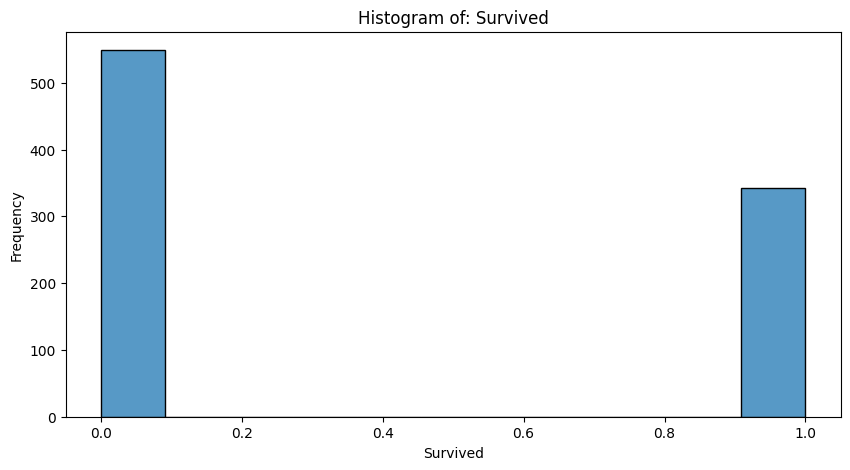

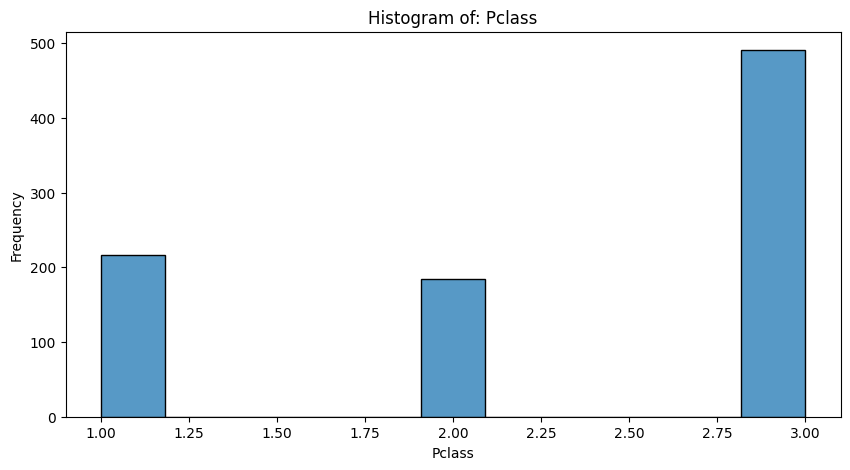

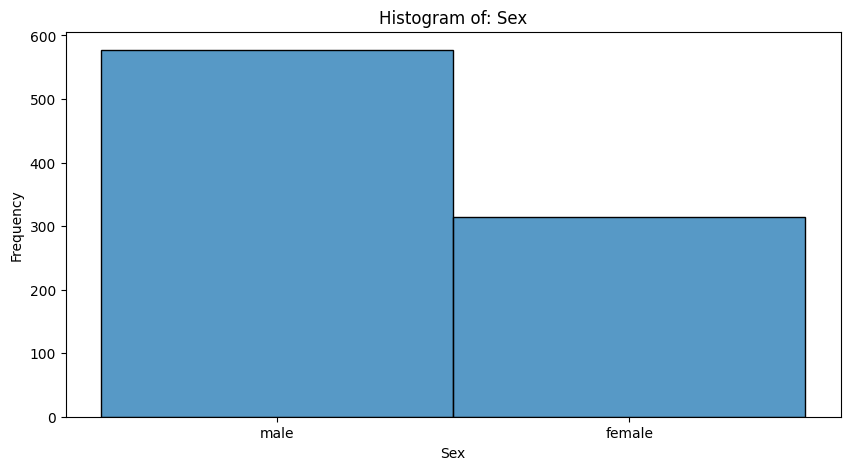

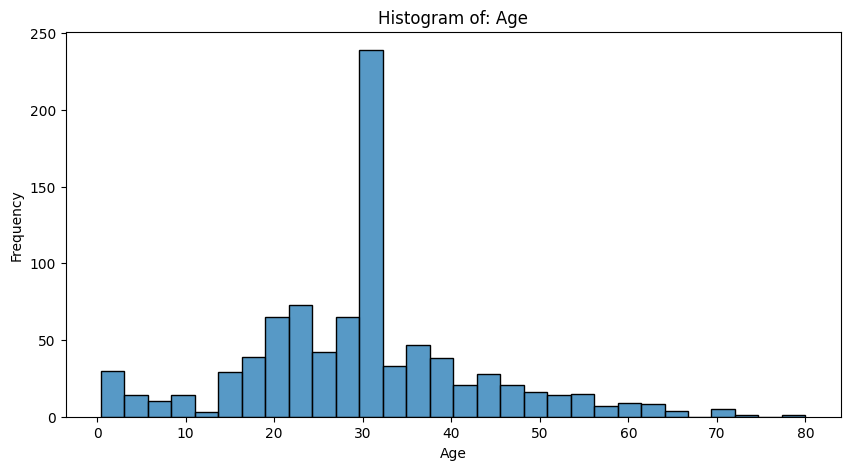

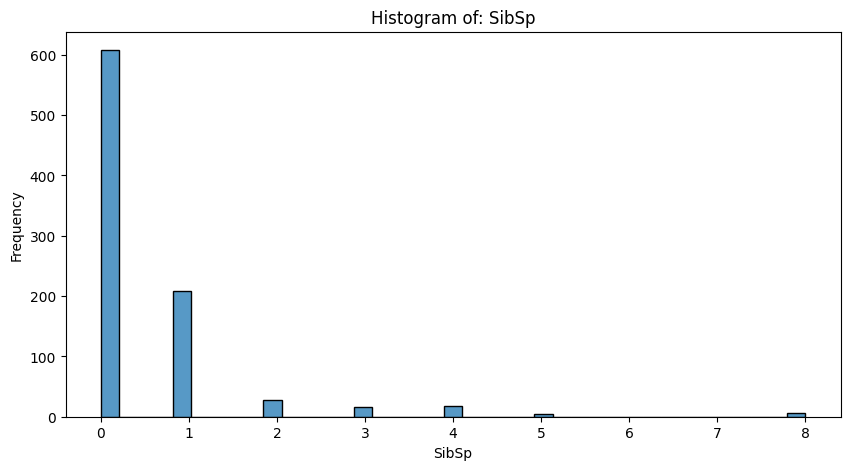

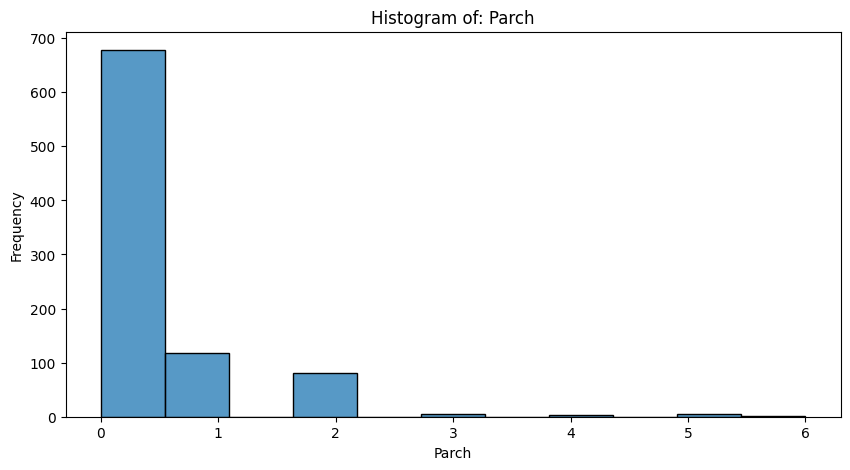

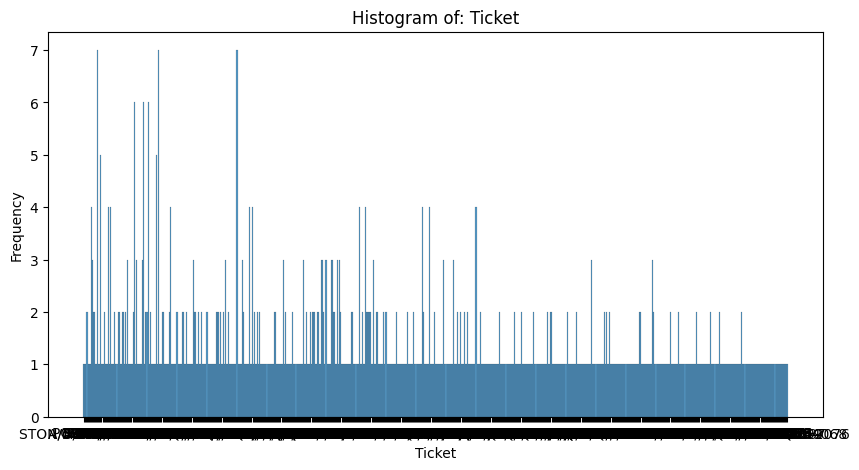

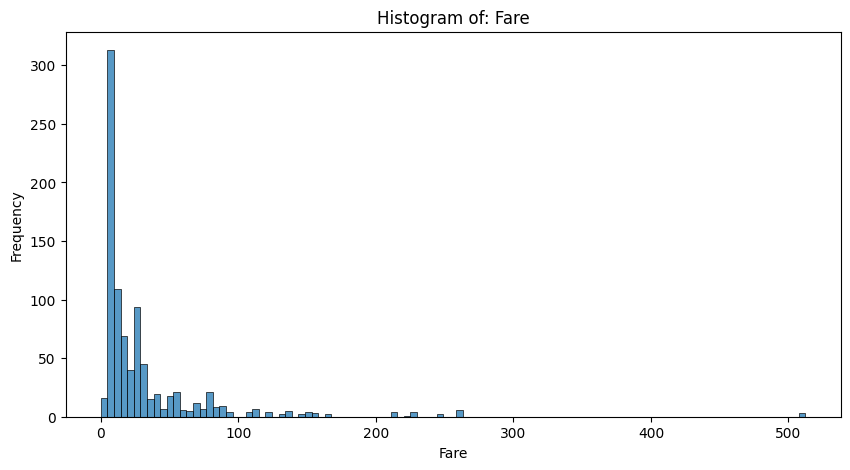

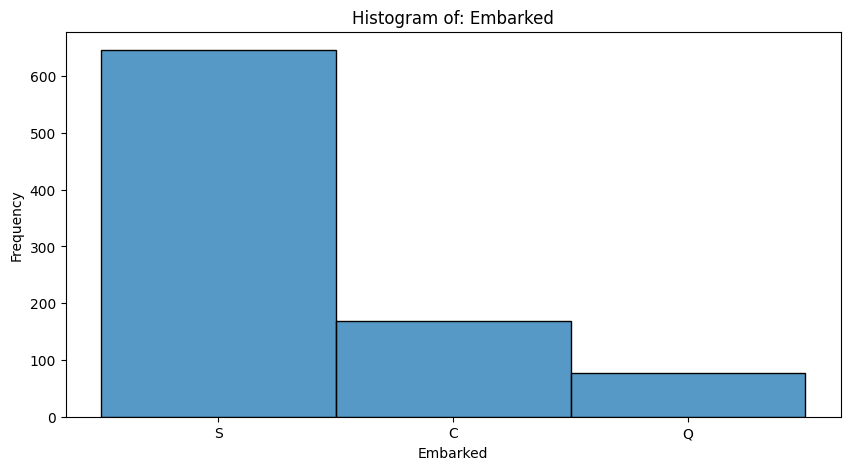

In [15]:
#Histogram
features = dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.histplot(dataset[feature])
    plt.title('Histogram of: ' + feature)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [18]:
#now encoding the categorical variables 
label_encoding = LabelEncoder()
dataset['Sex'] = label_encoding.fit_transform(dataset['Sex'])
dataset['Embarked'] = label_encoding.fit_transform(dataset['Embarked'])
dataset['Ticket'] = label_encoding.fit_transform(dataset['Ticket'])
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,1,22.000000,1,0,523,7.2500,2
1,1,1,0,38.000000,1,0,596,71.2833,0
2,1,3,0,26.000000,0,0,669,7.9250,2
3,1,1,0,35.000000,1,0,49,53.1000,2
4,0,3,1,35.000000,0,0,472,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,101,13.0000,2
887,1,1,0,19.000000,0,0,14,30.0000,2
888,0,3,0,29.699118,1,2,675,23.4500,2
889,1,1,1,26.000000,0,0,8,30.0000,0


In [19]:
#now plotting the correlation matrix
correlation_matrix = dataset.corr()
correlation_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
Survived,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,-0.164549,0.257307,-0.167675
Pclass,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,0.319869,-0.549500,0.162098
Sex,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,0.059372,-0.182333,0.108262
Age,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,-0.068848,0.091566,-0.026749
SibSp,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.079461,0.159651,0.068230
Parch,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.020003,0.216225,0.039798
Ticket,-0.164549,0.319869,0.059372,-0.068848,0.079461,0.020003,1.000000,-0.013885,-0.001729
Fare,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,-0.013885,1.000000,-0.224719
Embarked,-0.167675,0.162098,0.108262,-0.026749,0.068230,0.039798,-0.001729,-0.224719,1.000000


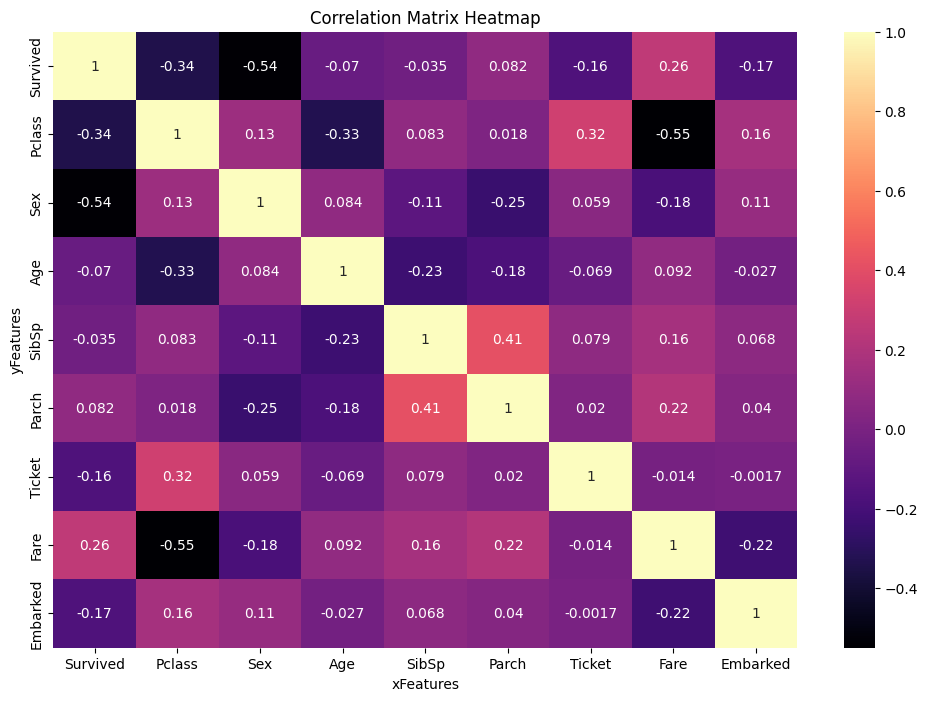

In [20]:
#now using heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap = 'magma')
plt.title('Correlation Matrix Heatmap')
plt.xlabel('xFeatures')
plt.ylabel('yFeatures')
plt.show()


In [21]:
#drop unnecessary columns
if 'Ticket' in dataset.columns:
    dataset.drop(['Ticket'], axis=1, inplace=True)
if 'SibSp' in dataset.columns:
    dataset.drop(['SibSp'], axis=1, inplace=True)
if 'Parch' in dataset.columns:
    dataset.drop(['Parch'], axis=1, inplace=True)
if 'Embarked' in dataset.columns:
    dataset.drop(['Embarked'], axis=1, inplace=True)
dataset

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.000000,7.2500
1,1,1,0,38.000000,71.2833
2,1,3,0,26.000000,7.9250
3,1,1,0,35.000000,53.1000
4,0,3,1,35.000000,8.0500
...,...,...,...,...,...
886,0,2,1,27.000000,13.0000
887,1,1,0,19.000000,30.0000
888,0,3,0,29.699118,23.4500
889,1,1,1,26.000000,30.0000


Pipeline

In [22]:
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()
numerical_cols = dataset.select_dtypes(include=['number']).drop('Survived', axis=1).columns.tolist()

In [28]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [29]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

In [34]:
X = dataset.drop('Survived', axis=1)
y = dataset['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

print(accuracy_score(y_test, dt_preds) * 100)

75.97765363128491


In [43]:
print(cr(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       105
           1       0.67      0.72      0.69        74

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



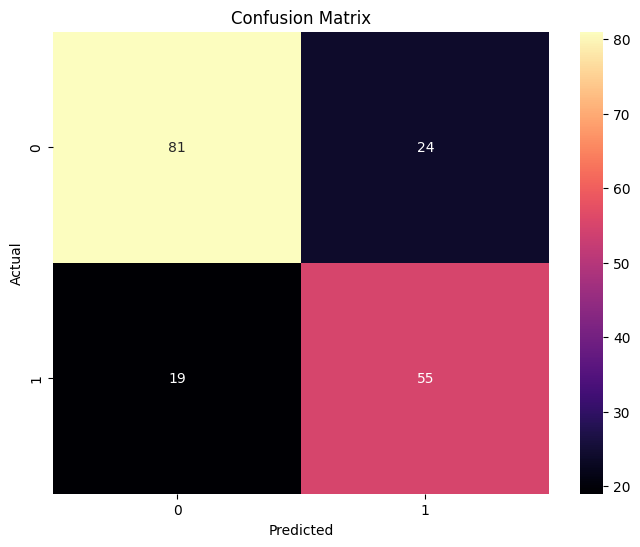

In [40]:
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.title('Confusion Matrix')
plt.show()

In [30]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [41]:
X = dataset.drop('Survived', axis=1)
y = dataset['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

print(accuracy_score(y_test, dt_preds) * 100)

73.74301675977654


In [44]:
print(cr(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       105
           1       0.67      0.72      0.69        74

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



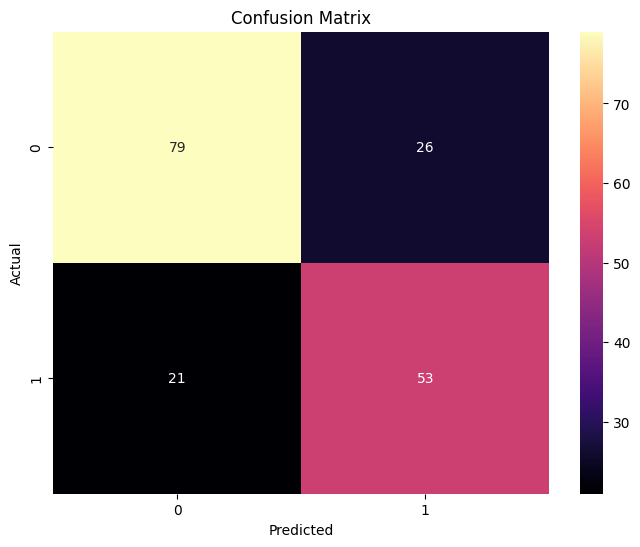

In [45]:
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.title('Confusion Matrix')
plt.show()

In [31]:
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

In [46]:
X = dataset.drop('Survived', axis=1)
y = dataset['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

print(accuracy_score(y_test, dt_preds) * 100)

74.86033519553072


In [48]:
print(cr(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       105
           1       0.68      0.74      0.71        74

    accuracy                           0.75       179
   macro avg       0.74      0.75      0.74       179
weighted avg       0.75      0.75      0.75       179



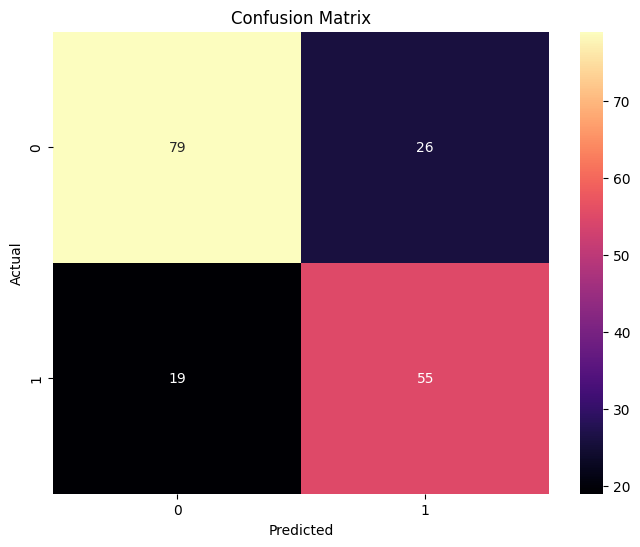

In [49]:
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.title('Confusion Matrix')
plt.show()

In [ ]:
dt_cv = cross_val_score(dt_pipeline, X_train, y_train, cv=5)
knn_cv = cross_val_score(knn_pipeline, X_train, y_train, cv=5)
nb_cv = cross_val_score(nb_pipeline, X_train, y_train, cv=5)

print("Decision Tree CV Mean:", dt_cv.mean() * 100)
print("KNN CV Mean:", knn_cv.mean() * 100)
print("Naive Bayes CV Mean:", nb_cv.mean() * 100)

Decision Tree CV Mean: 0.7683246331133656
KNN CV Mean: 0.8103319215995273
Naive Bayes CV Mean: 0.7808135526445386
